In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('project.db')

with open('/Users/katrina/Documents/25Fall/SQL/Final Project/entertainment.sql', 'r') as f:
    conn.executescript(f.read())

# 查看有哪些表
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

OperationalError: table Agents already exists

In [36]:
#part1主要用到的表
eng = pd.read_sql("SELECT * FROM Engagements;", conn)
ent = pd.read_sql("SELECT * FROM Entertainers;", conn)
cust = pd.read_sql("SELECT * FROM Customers;", conn)
agent = pd.read_sql("SELECT * FROM Agents;", conn)

eng.head(), ent.head(), cust.head(), agent.head()

(   EngagementNumber   StartDate     EndDate StartTime  StopTime  \
 0                 2  2017-09-02  2017-09-06  13:00:00  15:00:00   
 1                 3  2017-09-11  2017-09-16  13:00:00  15:00:00   
 2                 4  2017-09-12  2017-09-18  20:00:00  00:00:00   
 3                 5  2017-09-12  2017-09-15  16:00:00  19:00:00   
 4                 6  2017-09-11  2017-09-15  15:00:00  21:00:00   
 
    ContractPrice  CustomerID  AgentID  EntertainerID  
 0            200       10006        4           1004  
 1            590       10001        3           1005  
 2            470       10007        3           1004  
 3           1130       10006        5           1003  
 4           2300       10014        7           1008  ,
    EntertainerID        EntStageName       EntSSN        EntStreetAddress  \
 0           1001  Carol Peacock Trio  888-90-1121    4110 Old Redmond Rd.   
 1           1002              Topazz  888-50-1061           16 Maple Lane   
 2           1003  

In [ ]:
#三张必用图：
#图1：哪个 entertainer 被预订得最频繁？
#图2：收入最高的前 5个 entertainers
#图3：简单季节性分析（按月份看 top entertainers 的 booking）

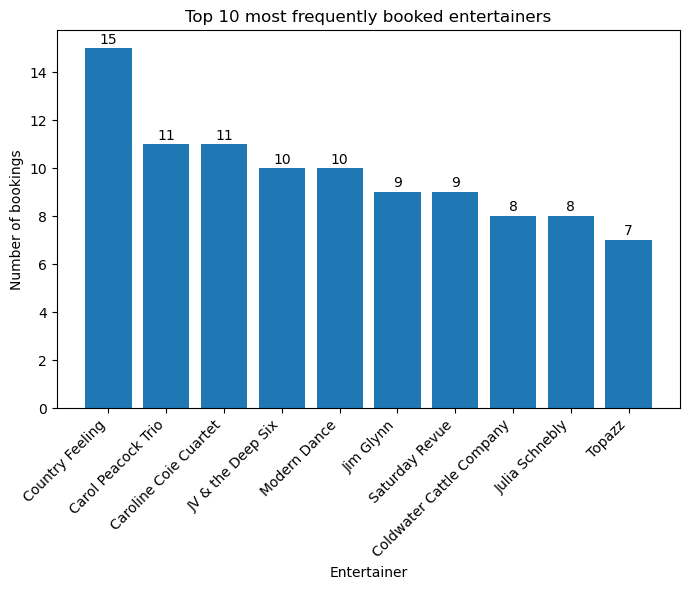

In [14]:
#图一：top 10 entertainer
# 预订次数统计
bookings = (eng
            .groupby('EntertainerID')['EngagementNumber']
            .count()
            .reset_index(name='total_bookings'))

# 合并艺人名字
bookings = bookings.merge(ent[['EntertainerID', 'EntStageName']],
                          on='EntertainerID',
                          how='left')

# 按次数从高到低排序
bookings = bookings.sort_values('total_bookings', ascending=False)

bookings.head()

#top10 histogram
top_n = 10
df = bookings.head(top_n)

plt.figure(figsize=(7, 6))  # ← 增大图宽度和高度
plt.bar(df['EntStageName'], df['total_bookings'])
plt.ylabel('Number of bookings')
plt.xlabel('Entertainer')
plt.title(f'Top {top_n} most frequently booked entertainers')

# 数字标签
for x, y in zip(df['EntStageName'], df['total_bookings']):
    plt.text(x, y + 0.2, str(y), ha='center')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()  # ← 自动调整布局，防止文字超出边框
plt.show()

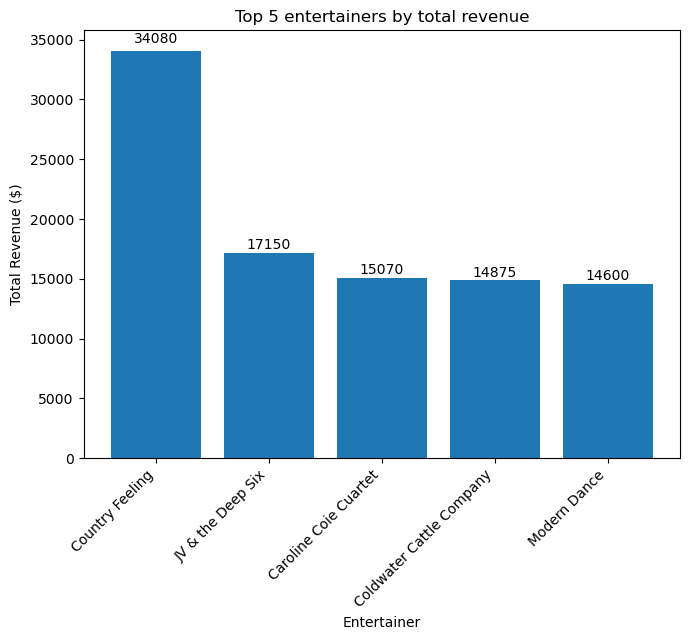

In [18]:
#图2: 收入最高的前 5 个 entertainers

#统计收入
# 每个艺人的总收入
revenue = (eng
           .groupby('EntertainerID')['ContractPrice']
           .sum()
           .reset_index(name='total_revenue'))

# 合并艺人名字
revenue = revenue.merge(ent[['EntertainerID', 'EntStageName']],
                        on='EntertainerID',
                        how='left')

# 从高到低排序，取前 5
top5_rev = revenue.sort_values('total_revenue', ascending=False).head(5)
top5_rev

#作图
plt.figure(figsize=(7, 6.5))
plt.bar(top5_rev['EntStageName'], top5_rev['total_revenue'])
plt.ylabel('Total Revenue ($)')
plt.xlabel('Entertainer')
plt.title('Top 5 entertainers by total revenue')

# 5. 标注数字（收入）
for x, y in zip(top5_rev['EntStageName'], top5_rev['total_revenue']):
    plt.text(x, y + 0.02 * y, f'{y:.0f}', ha='center')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

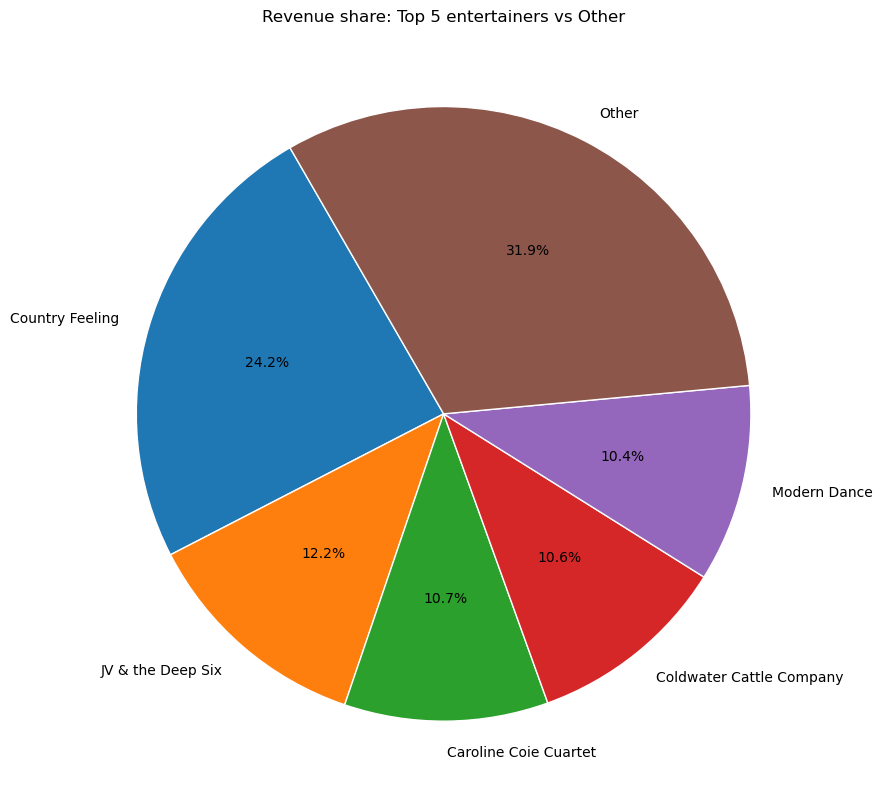

In [84]:
##饼图

# ===== Top 5 entertainers + `Other` grouped Pie Chart =====

# 1. 每个艺人的总收入
revenue_all = (
    eng.groupby('EntertainerID')['ContractPrice']
       .sum()
       .reset_index(name='total_revenue')
)

# 2. 合并艺人名字
revenue_all = revenue_all.merge(
    ent[['EntertainerID', 'EntStageName']],
    on='EntertainerID',
    how='left'
)

# 3. 按收入降序排序
revenue_all = revenue_all.sort_values('total_revenue', ascending=False)

# 4. 拿前5个
top5 = revenue_all.head(5).copy()

# 5. 计算 Top5 之外所有艺人的收入总和 → OTHER
other_total = revenue_all.iloc[5:]['total_revenue'].sum()

# 6. 创建 OTHER 行并加入 top5 DataFrame
other_row = pd.DataFrame({
    'EntStageName': ['Other'],
    'total_revenue': [other_total]
})

pie_data = pd.concat([top5[['EntStageName', 'total_revenue']], other_row], ignore_index=True)

# 7. 绘制饼图
plt.figure(figsize=(9, 9))

plt.pie(
    pie_data['total_revenue'],
    labels=pie_data['EntStageName'],
    autopct='%1.1f%%',
    startangle=120,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Revenue share: Top 5 entertainers vs Other')
plt.tight_layout()
plt.show()

In [22]:
#图3: Seasonal Analysis（按月份）

# 如果还没有转换日期 → 转换一下
eng['StartDate'] = pd.to_datetime(eng['StartDate'])
eng['Month'] = eng['StartDate'].dt.month

top5_ids = top5_rev['EntertainerID'].tolist()
eng_top5 = eng[eng['EntertainerID'].isin(top5_ids)]

# 统计月度 booking 数
month_counts = (eng_top5
                .groupby(['EntertainerID', 'Month'])['EngagementNumber']
                .count()
                .reset_index(name='num_engagements'))

# 合并艺名
month_counts = month_counts.merge(ent[['EntertainerID', 'EntStageName']],
                                  on='EntertainerID', how='left')



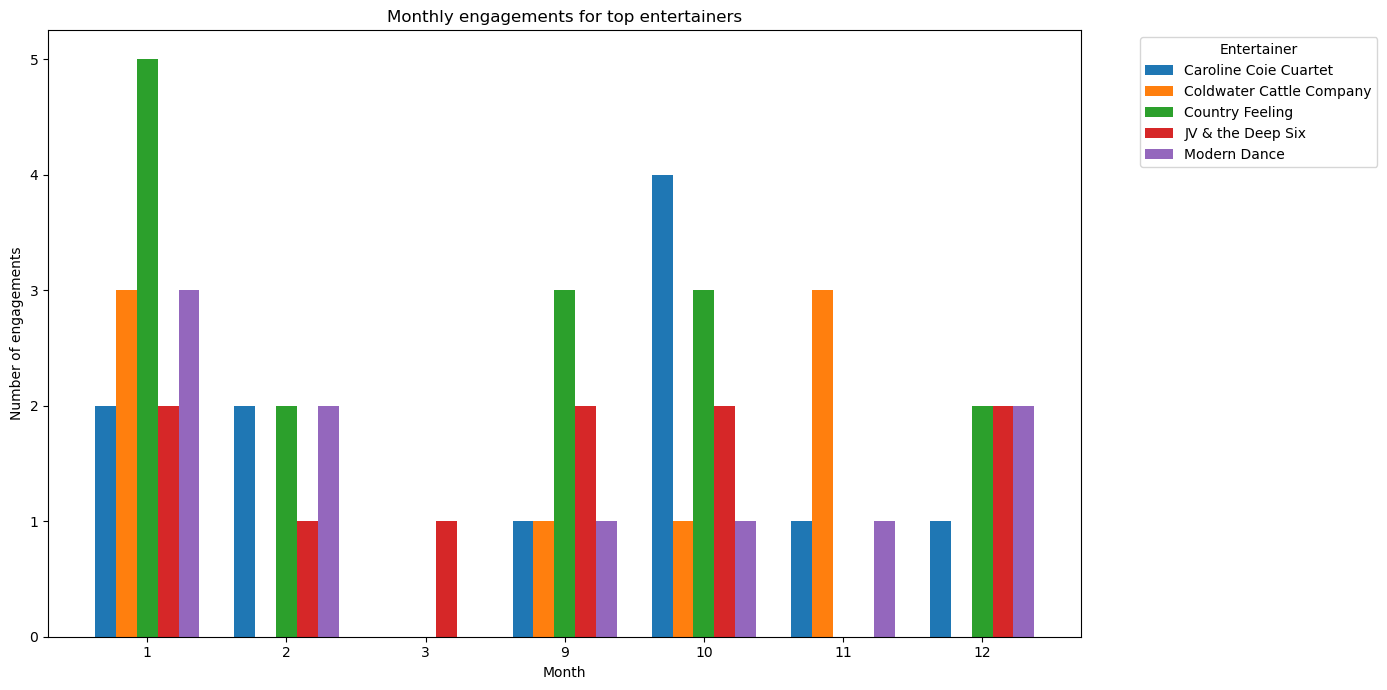

In [21]:
#bar chart
# ===== 图3：Seasonal trends using grouped bar chart =====

import numpy as np

plt.figure(figsize=(14, 7))

# 准备数据
pivot = month_counts.pivot(index='Month', columns='EntStageName', values='num_engagements').fillna(0)

months = pivot.index
entertainers = pivot.columns
x = np.arange(len(months))
width = 0.15   # 柱子宽度，Top5 刚好 5 个

# 画每个 entertainer 的柱状
for i, ent_name in enumerate(entertainers):
    plt.bar(x + i*width, pivot[ent_name], width, label=ent_name)

plt.xticks(x + width*2, months)  # 调整 x 轴刻度居中
plt.xlabel('Month')
plt.ylabel('Number of engagements')
plt.title('Monthly engagements for top entertainers')
plt.legend(title='Entertainer', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


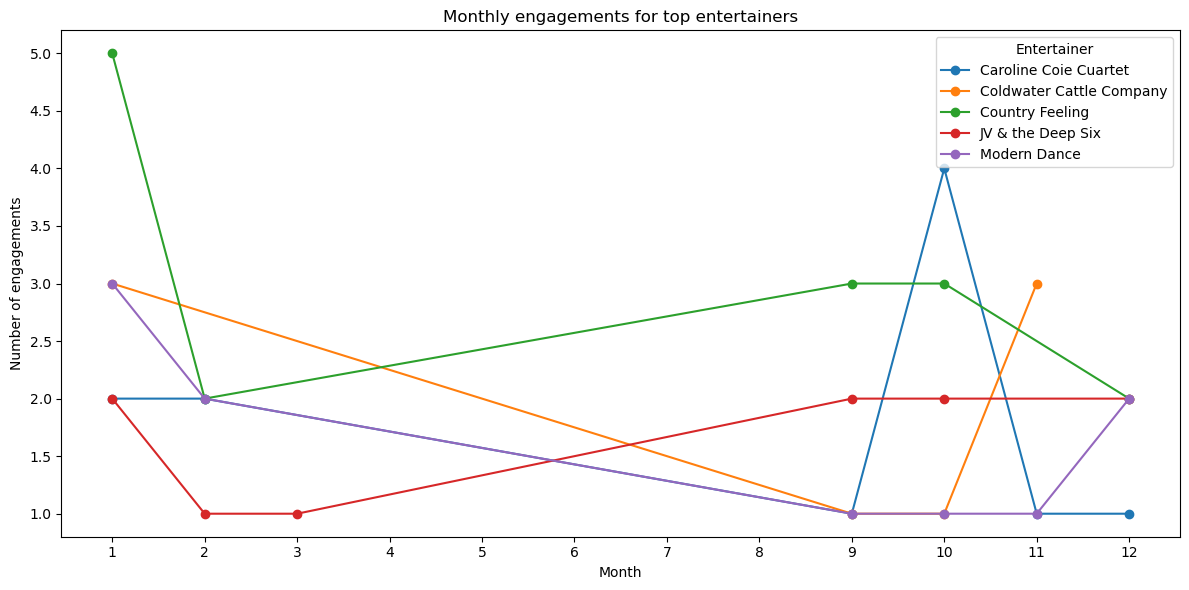

In [23]:
#折线图
# ===== 图3：Seasonal trends for top entertainers =====

plt.figure(figsize=(12, 6))

for name, group in month_counts.groupby('EntStageName'):
    group = group.sort_values('Month')
    plt.plot(group['Month'], group['num_engagements'], marker='o', label=name)

plt.xlabel('Month')
plt.ylabel('Number of engagements')
plt.title('Monthly engagements for top entertainers')

plt.xticks(range(1, 13))  # 显示 1-12 月
plt.legend(title='Entertainer')

plt.tight_layout()
plt.show()

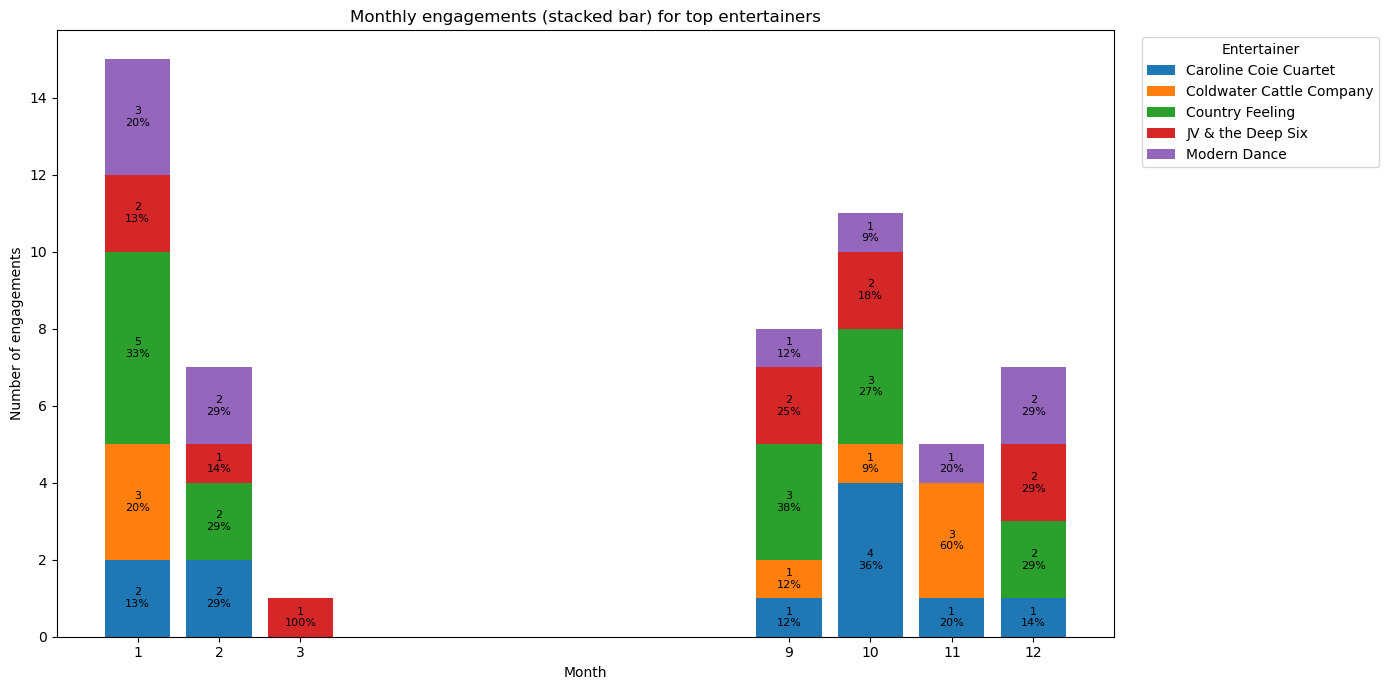

In [32]:
#！！！这个最好：既能观察到总量变化也能观察到个人
# ===== 图3B：Monthly stacked bar with values & percentages =====

plt.figure(figsize=(14, 7))

months = pivot.index
entertainers = pivot.columns

# 每个月的总 engagements
totals = pivot.sum(axis=1).values

bottom = np.zeros(len(months))

for ent_name in entertainers:
    values = pivot[ent_name].values

    # 绘图
    plt.bar(months, values, bottom=bottom, label=ent_name)

    # 添加 数字 + 百分比 标签
    for i, v in enumerate(values):
        if v > 0:
            y_bottom = bottom[i]
            y_center = y_bottom + v / 2
            pct = v / totals[i]

            plt.text(
                months[i], y_center,
                f'{int(v)}\n{pct:.0%}',
                ha='center', va='center', fontsize=8
            )

    bottom += values

# 图形格式
plt.xlabel('Month')
plt.ylabel('Number of engagements')
plt.title('Monthly engagements (stacked bar) for top entertainers')
plt.xticks(months)
plt.legend(title='Entertainer', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

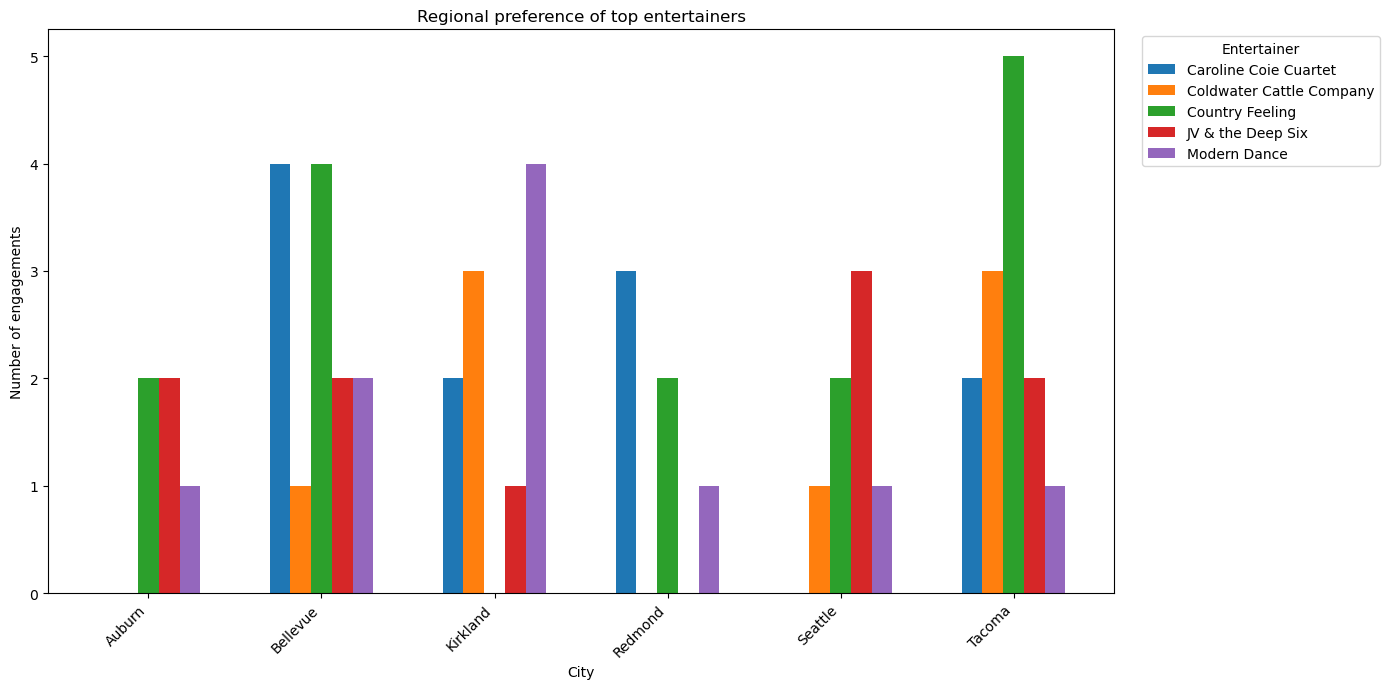

In [30]:
#4. Top entertainers 的地域偏好（Regional Preferences）

#Bar chart


# ===== 图4：Regional preferences for top entertainers =====

# 1. 把 top5 的 engagements 跟 customers 连起来，拿到城市信息
# 假设 cust 的城市字段名是 CustCity
eng_top5_region = eng_top5.merge(
    cust[['CustomerID', 'CustCity']],
    on='CustomerID',
    how='left'
)

# 2. 统计每个艺人 × 城市 的 engagement 数量
region_counts = (eng_top5_region
                 .groupby(['EntertainerID', 'CustCity'])['EngagementNumber']
                 .count()
                 .reset_index(name='num_engagements'))

# 3. 合并艺人名字
region_counts = region_counts.merge(
    ent[['EntertainerID', 'EntStageName']],
    on='EntertainerID',
    how='left'
)

# 4. 透视表：行=城市，列=艺人名
region_pivot = region_counts.pivot(
    index='CustCity',
    columns='EntStageName',
    values='num_engagements'
).fillna(0)

# 5. 绘制 grouped bar chart
import numpy as np
plt.figure(figsize=(14, 7))

cities = region_pivot.index
entertainers = region_pivot.columns
x = np.arange(len(cities))
width = 0.12  # 每个小柱子的宽度

for i, ent_name in enumerate(entertainers):
    plt.bar(x + i*width, region_pivot[ent_name], width, label=ent_name)

plt.xticks(x + width*(len(entertainers)-1)/2, cities, rotation=45, ha='right')
plt.xlabel('City')
plt.ylabel('Number of engagements')
plt.title('Regional preference of top entertainers')
plt.legend(title='Entertainer', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [29]:
eng.columns

Index(['EngagementNumber', 'StartDate', 'EndDate', 'StartTime', 'StopTime',
       'ContractPrice', 'CustomerID', 'AgentID', 'EntertainerID', 'Month'],
      dtype='object')

/var/folders/yt/_ds4qz2j48b7scsd09j581jm0000gn/T/ipykernel_38964/1361535722.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pct = h / totals[i]


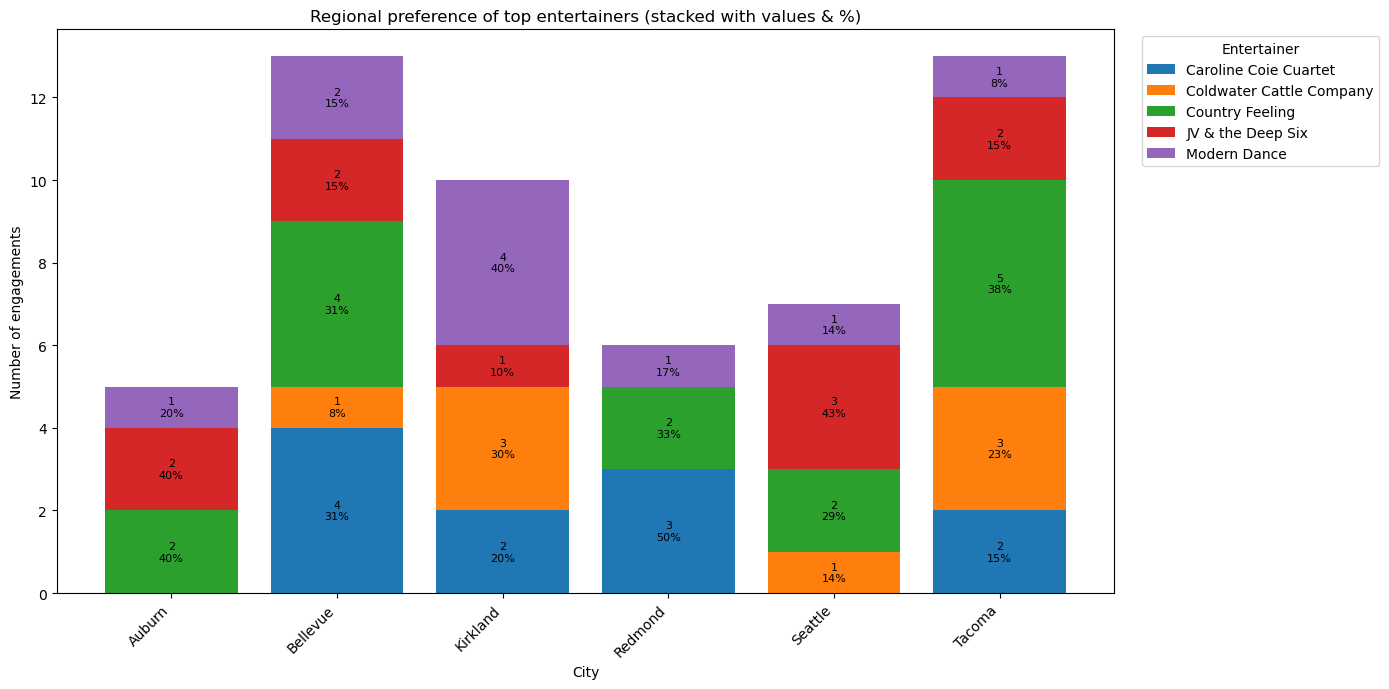

In [31]:
# ===== 图4（stacked+labels）：Regional preferences for top entertainers =====

# 1. 把 top5 的 engagements 跟 customers 连起来，拿到城市信息
eng_top5_region = eng_top5.merge(
    cust[['CustomerID', 'CustCity']],   # 如果列名不是 CustCity，就改成你的实际列名
    on='CustomerID',
    how='left'
)

# 2. 统计每个艺人 × 城市 的 engagement 数量
region_counts = (eng_top5_region
                 .groupby(['EntertainerID', 'CustCity'])['EngagementNumber']
                 .count()
                 .reset_index(name='num_engagements'))

# 3. 合并艺人名字
region_counts = region_counts.merge(
    ent[['EntertainerID', 'EntStageName']],
    on='EntertainerID',
    how='left'
)

# 4. 透视表：行=城市，列=艺人
region_pivot = region_counts.pivot(
    index='CustCity',
    columns='EntStageName',
    values='num_engagements'
).fillna(0)

# 5. 计算每个城市的总 engagement，用于百分比
totals = region_pivot.sum(axis=1)  # 每个城市的总数

plt.figure(figsize=(14, 7))

bottom = np.zeros(len(region_pivot.index))
cities = region_pivot.index
entertainers = region_pivot.columns

for ent_name in entertainers:
    heights = region_pivot[ent_name].values
    # 画当前 entertainer 的堆叠段
    plt.bar(cities, heights, bottom=bottom, label=ent_name)

    # 在每一段上加数字 + 百分比
    for i, h in enumerate(heights):
        if h > 0:  # 0 的就不用标了
            y_bottom = bottom[i]
            y_center = y_bottom + h / 2
            pct = h / totals[i]
            plt.text(
                i, y_center,
                f'{int(h)}\n{pct:.0%}',
                ha='center', va='center', fontsize=8
            )

    bottom += heights  # 更新堆叠底部

plt.xticks(range(len(cities)), cities, rotation=45, ha='right')
plt.xlabel('City')
plt.ylabel('Number of engagements')
plt.title('Regional preference of top entertainers (stacked with values & %)')
plt.legend(title='Entertainer', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

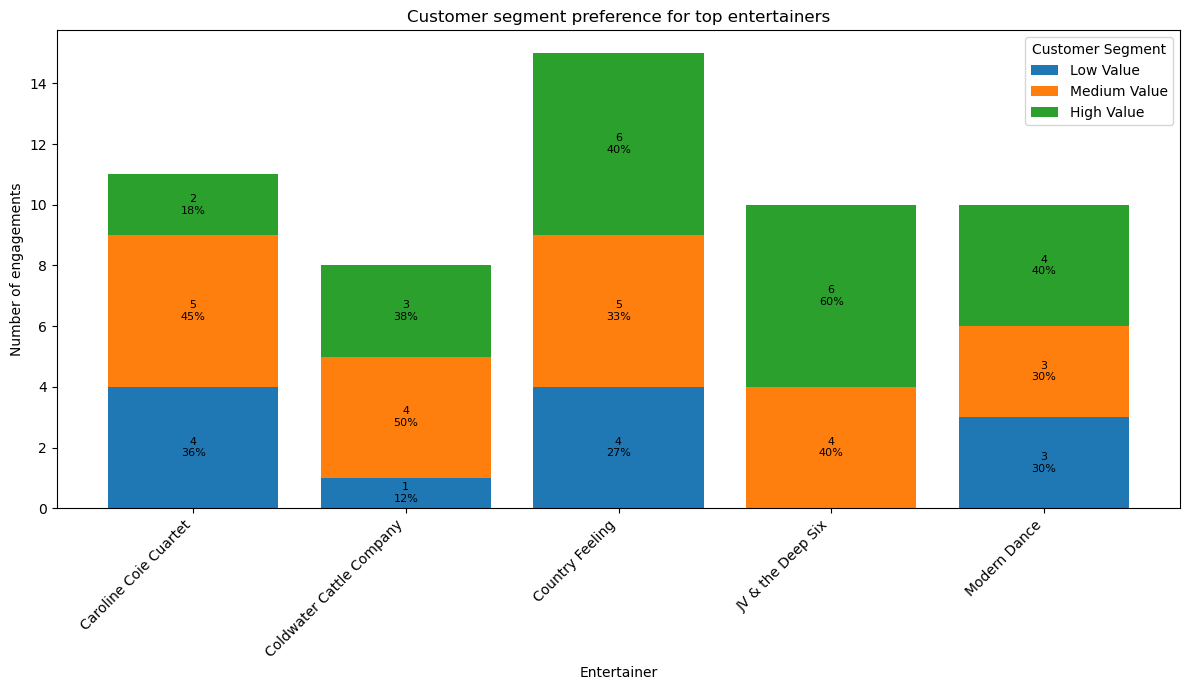

In [34]:
# ===== 图5：Customer segment preferences =====

# 1. 按客户算总消费
cust_spend = (eng
              .groupby('CustomerID')['ContractPrice']
              .sum()
              .reset_index(name='total_spend'))

# 2. 用四分位数划分 High / Medium / Low
q1, q3 = cust_spend['total_spend'].quantile([0.25, 0.75])

def label_segment(x):
    if x >= q3:
        return 'High Value'
    elif x <= q1:
        return 'Low Value'
    else:
        return 'Medium Value'

cust_spend['CustomerSegment'] = cust_spend['total_spend'].apply(label_segment)

# 3. 把 segment 合并回 top5 的 engagements
eng_top5_seg = eng_top5.merge(
    cust_spend[['CustomerID', 'CustomerSegment']],
    on='CustomerID',
    how='left'
)

# 4. 统计每个艺人 × segment 的 engagements 数量
seg_counts = (eng_top5_seg
              .groupby(['EntertainerID', 'CustomerSegment'])['EngagementNumber']
              .count()
              .reset_index(name='num_engagements'))

# 5. 合并艺人名字
seg_counts = seg_counts.merge(
    ent[['EntertainerID', 'EntStageName']],
    on='EntertainerID', how='left'
)

# 6. 透视表：行=艺人，列=segment
seg_pivot = seg_counts.pivot(
    index='EntStageName',
    columns='CustomerSegment',
    values='num_engagements'
).fillna(0)

# 为了统一顺序
seg_pivot = seg_pivot[['Low Value', 'Medium Value', 'High Value']]

# 7. 画堆叠柱状图
plt.figure(figsize=(12, 7))

x = np.arange(len(seg_pivot.index))

# 每个艺人的总 engagements，用来算百分比
totals = seg_pivot.sum(axis=1).values

bottom = np.zeros(len(seg_pivot.index))

for seg in seg_pivot.columns:
    values = seg_pivot[seg].values

    # 画当前 segment 的堆叠部分
    plt.bar(x, values, bottom=bottom, label=seg)

    # 在每一段上加：数量 + 百分比
    for i, v in enumerate(values):
        if v > 0:
            y_bottom = bottom[i]
            y_center = y_bottom + v / 2
            pct = v / totals[i]

            plt.text(
                x[i], y_center,
                f'{int(v)}\n{pct:.0%}',
                ha='center', va='center', fontsize=8
            )

    bottom += values  # 更新堆叠高度

plt.xticks(x, seg_pivot.index, rotation=45, ha='right')
plt.xlabel('Entertainer')
plt.ylabel('Number of engagements')
plt.title('Customer segment preference for top entertainers')
plt.legend(title='Customer Segment')

plt.tight_layout()
plt.show()

In [37]:
agent.columns

Index(['AgentID', 'AgtFirstName', 'AgtLastName', 'AgtStreetAddress', 'AgtCity',
       'AgtState', 'AgtZipCode', 'AgtPhoneNumber', 'DateHired', 'Salary',
       'CommissionRate'],
      dtype='object')

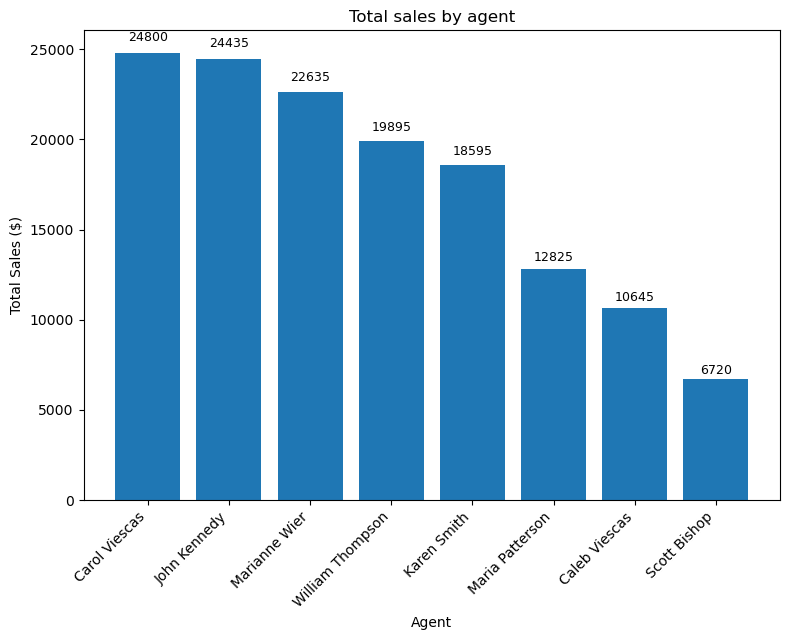

In [40]:
# Agent Q1:
# ------ Q1: 每个 agent 在每个客户上的收入 ------
agent_client_rev = (eng
    .groupby(['AgentID', 'CustomerID'])['ContractPrice']
    .sum()
    .reset_index(name='client_revenue')
)

# 合并 agent 姓名
agent_client_rev = agent_client_rev.merge(
    agent[['AgentID', 'AgtFirstName', 'AgtLastName']],
    on='AgentID',
    how='left'
)

agent_client_rev['agent_name'] = agent_client_rev['AgtFirstName'] + ' ' + agent_client_rev['AgtLastName']

# ------ 汇总到 agent 级别：总销售、客户数、平均每客户收入、最大客户收入、最大客户占比 ------
agent_summary = (agent_client_rev
    .groupby(['AgentID', 'agent_name'])['client_revenue']
    .agg(num_clients='count',
         total_sales='sum',
         avg_rev_per_client='mean',
         top_client_rev='max')
    .reset_index()
)

agent_summary['top_client_share'] = agent_summary['top_client_rev'] / agent_summary['total_sales']

# 按总销售从高到低排
agent_summary = agent_summary.sort_values('total_sales', ascending=False)

agent_summary


#作图
# ===== Agent Q1 - Figure 1: Total sales by agent =====

plt.figure(figsize=(8, 6.5))

x = np.arange(len(agent_summary))
plt.bar(x, agent_summary['total_sales'])

plt.xticks(x, agent_summary['agent_name'], rotation=45, ha='right')
plt.xlabel('Agent')
plt.ylabel('Total Sales ($)')
plt.title('Total sales by agent')

# 在柱子顶部标注总销售额
for i, v in enumerate(agent_summary['total_sales']):
    plt.text(i, v + 0.02 * v, f'{int(v)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



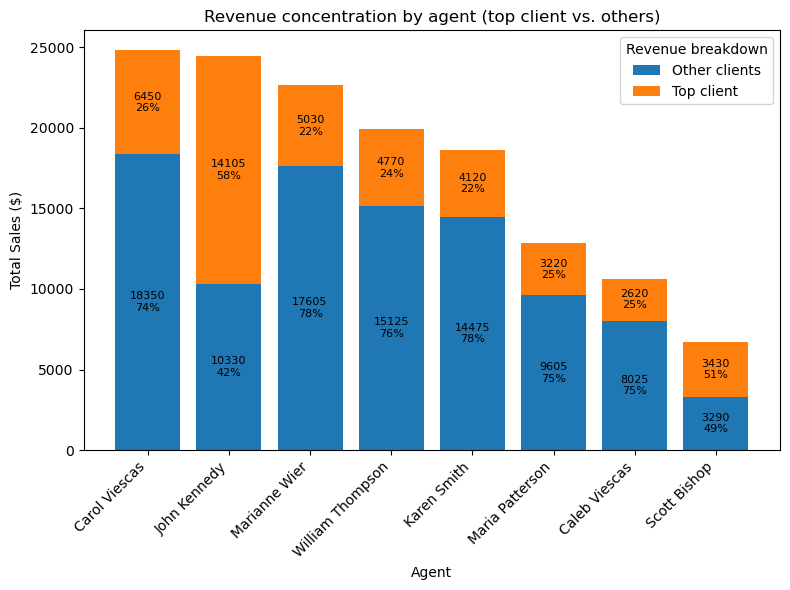

In [42]:
#Q1 图二：集中度

# ===== Agent Q1 - Figure 2: Revenue concentration by agent =====

# 构造 Top client vs Other clients 的透视表
top_vs_other = agent_summary.copy()
top_vs_other['other_clients_rev'] = top_vs_other['total_sales'] - top_vs_other['top_client_rev']

plot_df = top_vs_other[['agent_name', 'top_client_rev', 'other_clients_rev']]
plot_df = plot_df.set_index('agent_name')

plt.figure(figsize=(8, 6))

x = np.arange(len(plot_df.index))
bottom = np.zeros(len(plot_df.index))

# 堆叠两层：Top client + Others
segments = ['other_clients_rev', 'top_client_rev']
labels = ['Other clients', 'Top client']

for seg, label in zip(segments, labels):
    values = plot_df[seg].values
    plt.bar(x, values, bottom=bottom, label=label)

    # 添加 数字+百分比（分别对 top client 和 other 标注）
    totals = plot_df.sum(axis=1).values
    for i, v in enumerate(values):
        if v > 0:
            y_bottom = bottom[i]
            y_center = y_bottom + v / 2
            pct = v / totals[i]
            plt.text(
                x[i],
                y_center,
                f'{int(v)}\n{pct:.0%}',
                ha='center',
                va='center',
                fontsize=8
            )

    bottom += values

plt.xticks(x, plot_df.index, rotation=45, ha='right')
plt.xlabel('Agent')
plt.ylabel('Total Sales ($)')
plt.title('Revenue concentration by agent (top client vs. others)')
plt.legend(title='Revenue breakdown')

plt.tight_layout()
plt.show()

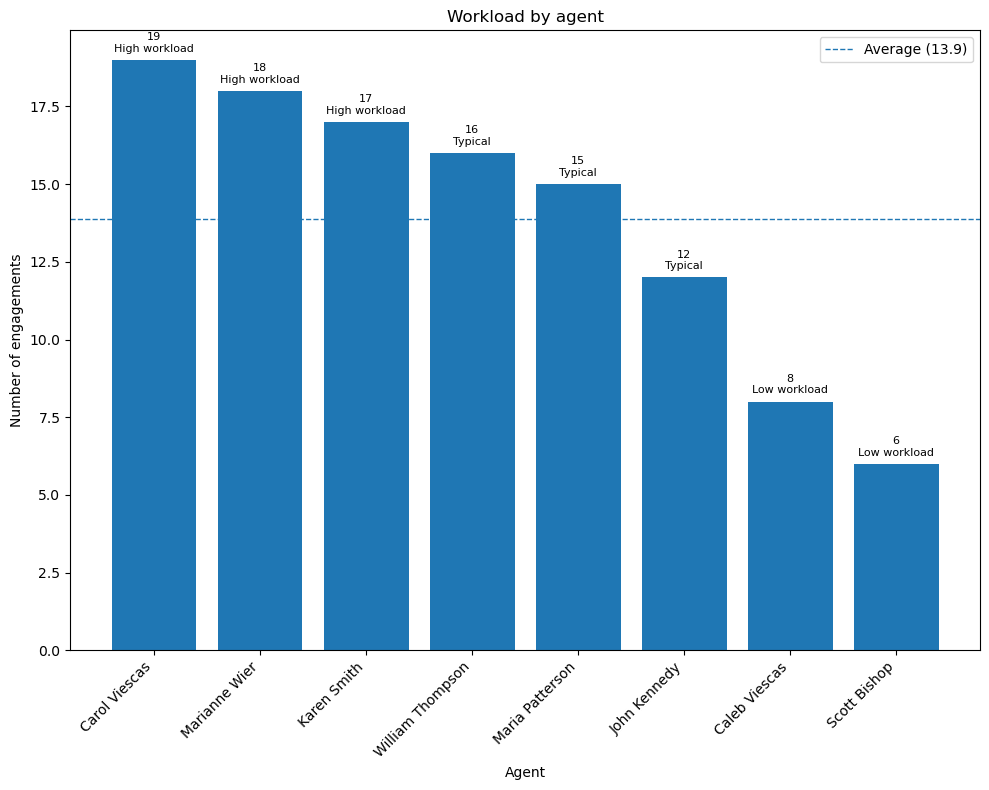

In [49]:
# ===== Agent Q2: 工作量汇总 =====

# 每个 Agent 的 engagements & 客户数
agent_workload = (eng
    .groupby('AgentID')
    .agg(num_engagements=('EngagementNumber', 'count'),
         num_clients=('CustomerID', 'nunique'))
    .reset_index()
)

# 合并姓名
agent_workload = agent_workload.merge(
    agent[['AgentID', 'AgtFirstName', 'AgtLastName']],
    on='AgentID',
    how='left'
)
agent_workload['agent_name'] = agent_workload['AgtFirstName'] + ' ' + agent_workload['AgtLastName']

# 计算平均工作量
avg_engagements = agent_workload['num_engagements'].mean()
agent_workload['workload_ratio'] = agent_workload['num_engagements'] / avg_engagements

def label_workload(r):
    if r >= 1.2:
        return 'High workload'
    elif r <= 0.8:
        return 'Low workload'
    else:
        return 'Typical'

agent_workload['workload_category'] = agent_workload['workload_ratio'].apply(label_workload)

# 为了好看按 num_engagements 排序
agent_workload = agent_workload.sort_values('num_engagements', ascending=False)

agent_workload



# ===== Agent Q2 - Figure: Workload by agent =====

plt.figure(figsize=(10,8))

x = np.arange(len(agent_workload))
plt.bar(x, agent_workload['num_engagements'])

# 平均线
plt.axhline(avg_engagements, linestyle='--', linewidth=1, label=f'Average ({avg_engagements:.1f})')

plt.xticks(x, agent_workload['agent_name'], rotation=45, ha='right')
plt.xlabel('Agent')
plt.ylabel('Number of engagements')
plt.title('Workload by agent')

# 标注：订单数 + 工作量类别
for i, (n, cat) in enumerate(zip(agent_workload['num_engagements'], agent_workload['workload_category'])):
    plt.text(i, n + 0.2, f'{n}\n{cat}', ha='center', va='bottom', fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

In [50]:
####Customer Analysis

In [55]:
mp = pd.read_sql("SELECT * FROM Musical_Preferences;", conn)
ms = pd.read_sql("SELECT * FROM Musical_Styles;", conn)

mp.head(5), ms.head(5)

Index(['CustomerID', 'StyleID', 'PreferenceSeq'], dtype='object')

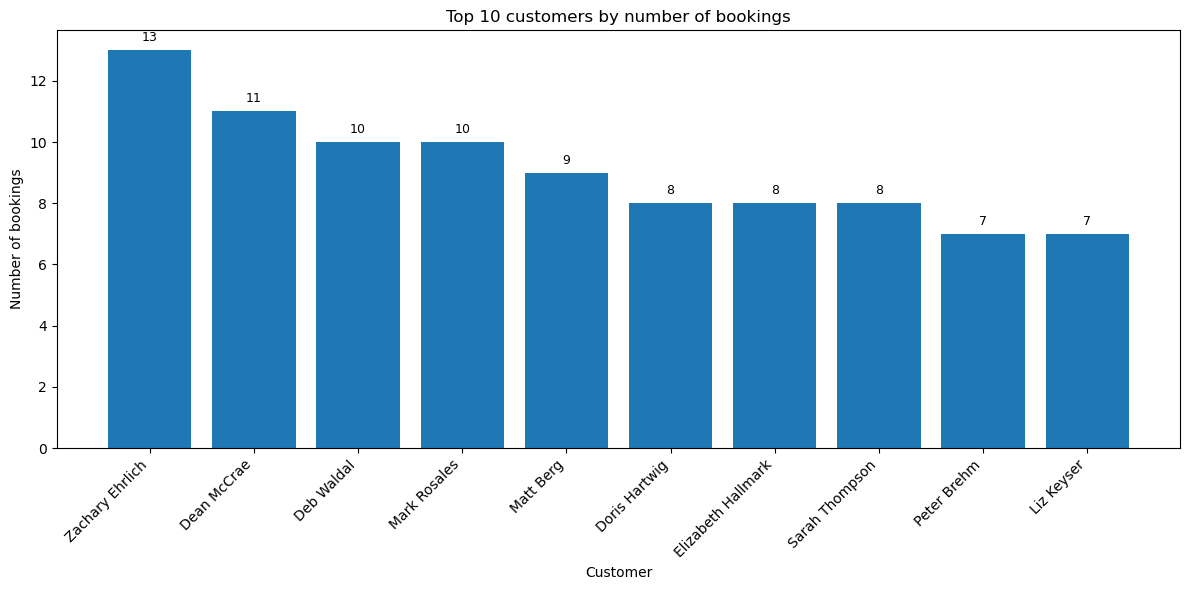

In [57]:
# ===== Customer Q1: Top customers by number of bookings =====

# 每个客户的总预订次数
cust_bookings = (
    eng.groupby('CustomerID')['EngagementNumber']
       .count()
       .reset_index(name='total_bookings')
)

# 合并客户姓名
cust_bookings = cust_bookings.merge(
    cust[['CustomerID', 'CustFirstName', 'CustLastName']],
    on='CustomerID',
    how='left'
)

cust_bookings['customer_name'] = (
    cust_bookings['CustFirstName'] + ' ' + cust_bookings['CustLastName']
)

# 按预订次数从高到低排序
cust_bookings = cust_bookings.sort_values('total_bookings', ascending=False)
cust_bookings.head()

#1.2 可视化：Top 10 客户预订次数（柱状图 + 数字）python复制代码
# ===== Figure C1: Top 10 customers by bookings =====

top_n = 10
df = cust_bookings.head(top_n)

plt.figure(figsize=(12, 6))
x = np.arange(len(df))

plt.bar(x, df['total_bookings'])
plt.xticks(x, df['customer_name'], rotation=45, ha='right')
plt.xlabel('Customer')
plt.ylabel('Number of bookings')
plt.title(f'Top {top_n} customers by number of bookings')

# 顶部标注具体次数
for i, v in enumerate(df['total_bookings']):
    plt.text(i, v + 0.2, str(int(v)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

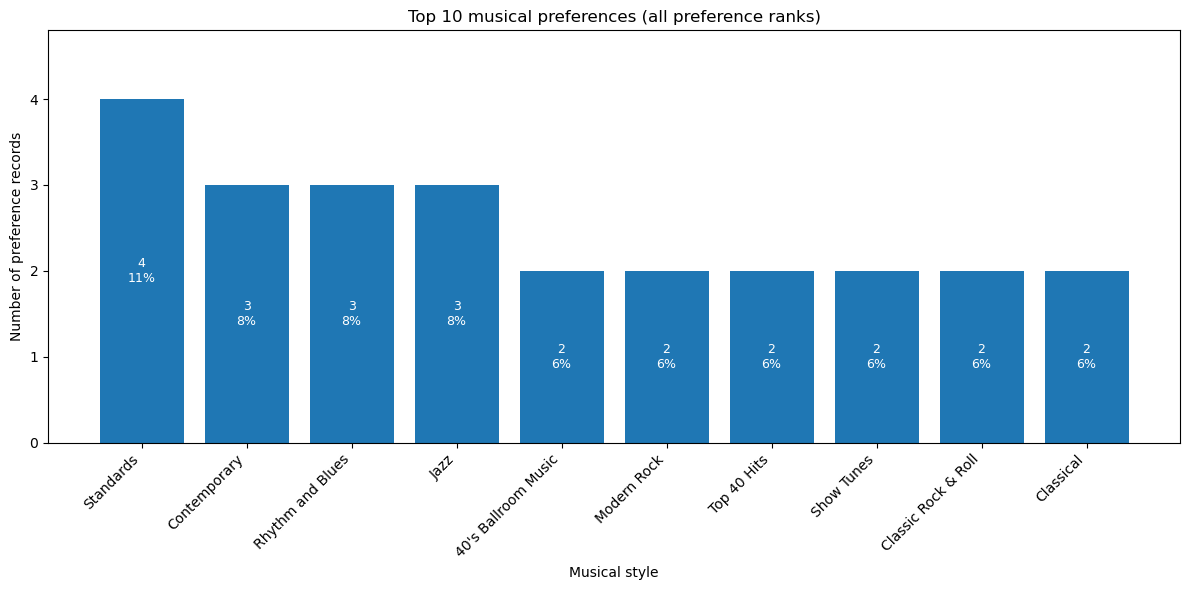

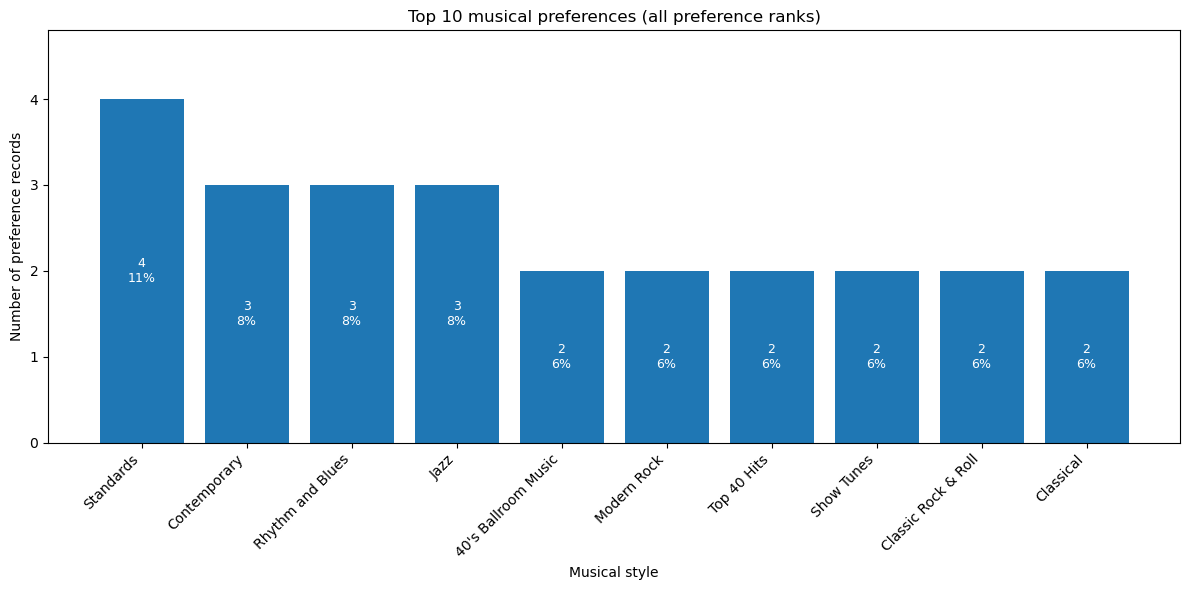

In [87]:
# ===== Customer Q2: Most common musical preferences (match SQL in PDF) =====

# 1. 不筛选 PreferenceSeq：使用所有偏好记录
prefs_all = mp.merge(
    ms[['StyleID', 'StyleName']],
    on='StyleID',
    how='left'
)

# 2. 统计每种风格在 Musical_Preferences 表中一共出现了多少次
style_counts = (
    prefs_all.groupby('StyleName')['StyleID']
             .count()
             .reset_index(name='preference_count')
)

# 3. 按出现次数从高到低排序
style_counts = style_counts.sort_values('preference_count', ascending=False)

# 4. 计算百分比（占所有偏好记录的比例）
total_prefs = style_counts['preference_count'].sum()
style_counts['pct'] = style_counts['preference_count'] / total_prefs

# ===== Figure C2: Top 10 musical preferences (visualization) =====

top_n = 10
df = style_counts.head(top_n).copy()

plt.figure(figsize=(12, 6))
x = np.arange(len(df))

plt.bar(x, df['preference_count'])
plt.xticks(x, df['StyleName'], rotation=45, ha='right')
plt.xlabel('Musical style')
plt.ylabel('Number of preference records')
plt.title(f'Top {top_n} musical preferences (all preference ranks)')

max_cnt = df['preference_count'].max()
plt.ylim(0, max_cnt + 0.8)

# 在柱子内部标 “次数 + 百分比”
for i, (cnt, pct) in enumerate(zip(df['preference_count'], df['pct'])):
    plt.text(
        x[i],
        cnt / 2,                       # 柱子中间
        f'{int(cnt)}\n{pct:.0%}',      # 例如：2 换行 13%
        ha='center',
        va='center',
        fontsize=9,
        color='white'
    )

plt.tight_layout()
plt.show()
# ===== Customer Q2: Most common musical preferences (match SQL in PDF) =====

# 1. 不筛选 PreferenceSeq：使用所有偏好记录
prefs_all = mp.merge(
    ms[['StyleID', 'StyleName']],
    on='StyleID',
    how='left'
)

# 2. 统计每种风格在 Musical_Preferences 表中一共出现了多少次
style_counts = (
    prefs_all.groupby('StyleName')['StyleID']
             .count()
             .reset_index(name='preference_count')
)

# 3. 按出现次数从高到低排序
style_counts = style_counts.sort_values('preference_count', ascending=False)

# 4. 计算百分比（占所有偏好记录的比例）
total_prefs = style_counts['preference_count'].sum()
style_counts['pct'] = style_counts['preference_count'] / total_prefs

# ===== Figure C2: Top 10 musical preferences (visualization) =====

top_n = 10
df = style_counts.head(top_n).copy()

plt.figure(figsize=(12, 6))
x = np.arange(len(df))

plt.bar(x, df['preference_count'])
plt.xticks(x, df['StyleName'], rotation=45, ha='right')
plt.xlabel('Musical style')
plt.ylabel('Number of preference records')
plt.title(f'Top {top_n} musical preferences (all preference ranks)')

max_cnt = df['preference_count'].max()
plt.ylim(0, max_cnt + 0.8)

# 在柱子内部标 “次数 + 百分比”
for i, (cnt, pct) in enumerate(zip(df['preference_count'], df['pct'])):
    plt.text(
        x[i],
        cnt / 2,                       # 柱子中间
        f'{int(cnt)}\n{pct:.0%}',      # 例如：2 换行 13%
        ha='center',
        va='center',
        fontsize=9,
        color='white'
    )

plt.tight_layout()
plt.show()

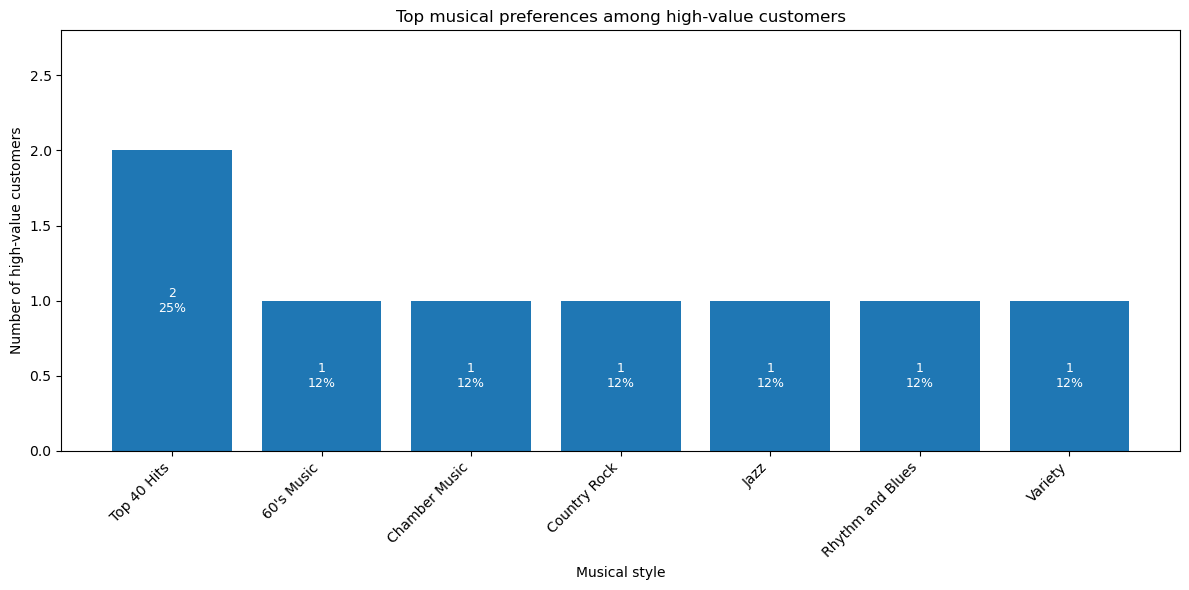

In [70]:
# ===== Customer Q3: Musical preferences of high-value customers =====

# 1. 找出高频客户（total_bookings >= 8）
high_freq = (
    eng.groupby('CustomerID')['EngagementNumber']
       .count()
       .reset_index(name='total_bookings')
)
high_freq = high_freq[high_freq['total_bookings'] >= 8]

# 2. 取这些客户的 top preference
top_prefs = mp[mp['PreferenceSeq'] == 1]

hf_prefs = high_freq.merge(
    top_prefs[['CustomerID', 'StyleID']],
    on='CustomerID',
    how='left'
)

hf_prefs = hf_prefs.merge(
    ms[['StyleID', 'StyleName']],
    on='StyleID',
    how='left'
)

# 3. 按风格统计有多少高价值客户选择该风格为 top preference
hf_style_counts = (
    hf_prefs.groupby('StyleName')['CustomerID']
            .nunique()
            .reset_index(name='num_high_value_customers')
)

hf_style_counts = hf_style_counts.sort_values(
    'num_high_value_customers', ascending=False
)

total_hv = hf_style_counts['num_high_value_customers'].sum()
hf_style_counts['pct'] = hf_style_counts['num_high_value_customers'] / total_hv
hf_style_counts




# ===== Figure C3: Musical preferences of high-value customers =====

df_hv = hf_style_counts.copy()

plt.figure(figsize=(12, 6))
x = np.arange(len(df_hv))

plt.bar(x, df_hv['num_high_value_customers'])
plt.xticks(x, df_hv['StyleName'], rotation=45, ha='right')
plt.xlabel('Musical style')
plt.ylabel('Number of high-value customers')
plt.title('Top musical preferences among high-value customers')

max_cnt_hv = df_hv['num_high_value_customers'].max()
plt.ylim(0, max_cnt_hv + 0.8)

# ⭐ 同样：文字放在柱子内部
for i, (cnt, pct) in enumerate(zip(df_hv['num_high_value_customers'], df_hv['pct'])):
    label_y = cnt / 2
    plt.text(
        x[i], label_y,
        f'{int(cnt)}\n{pct:.0%}',
        ha='center', va='center', fontsize=9, color='white'
    )

plt.tight_layout()
plt.show()

In [ ]:
######替代图

In [ ]:
#Engagement %

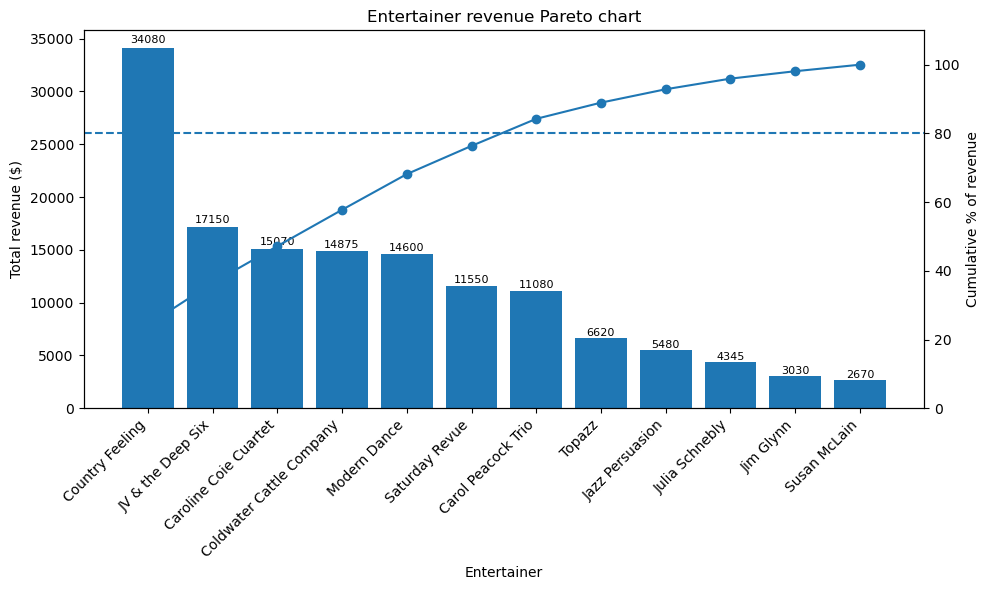

In [71]:
#1:帕累托（所有艺人）
# ===== 图：Entertainer revenue Pareto chart =====

# 1. 计算每个艺人的总收入
revenue = (
    eng.groupby('EntertainerID')['ContractPrice']
       .sum()
       .reset_index(name='total_revenue')
)

# 2. 合并艺人名字
revenue = revenue.merge(
    ent[['EntertainerID', 'EntStageName']],
    on='EntertainerID',
    how='left'
)

# 3. 按收入从高到低排序
revenue = revenue.sort_values('total_revenue', ascending=False)

# 4. 计算累计收入及累计占比
revenue['cum_revenue'] = revenue['total_revenue'].cumsum()
total_rev = revenue['total_revenue'].sum()
revenue['cum_pct'] = revenue['cum_revenue'] / total_rev * 100

# 5. 画帕累托图：柱状图 + 折线图（双纵轴）
fig, ax1 = plt.subplots(figsize=(10, 6))

x = range(len(revenue))

# 柱状图：单个艺人收入
ax1.bar(x, revenue['total_revenue'])
ax1.set_xlabel('Entertainer')
ax1.set_ylabel('Total revenue ($)')
ax1.set_title('Entertainer revenue Pareto chart')

ax1.set_xticks(list(x))
ax1.set_xticklabels(revenue['EntStageName'], rotation=45, ha='right')

# 在柱子上标出收入数值
for i, y in enumerate(revenue['total_revenue']):
    ax1.text(
        i, y + 0.01 * y,
        f'{y:.0f}',
        ha='center', va='bottom', fontsize=8
    )

# 第二个 y 轴：累计百分比折线
ax2 = ax1.twinx()
ax2.plot(x, revenue['cum_pct'], marker='o')
ax2.set_ylabel('Cumulative % of revenue')
ax2.set_ylim(0, 110)

# 标一条 80% 的虚线
ax2.axhline(80, linestyle='--')

plt.tight_layout()
plt.show()

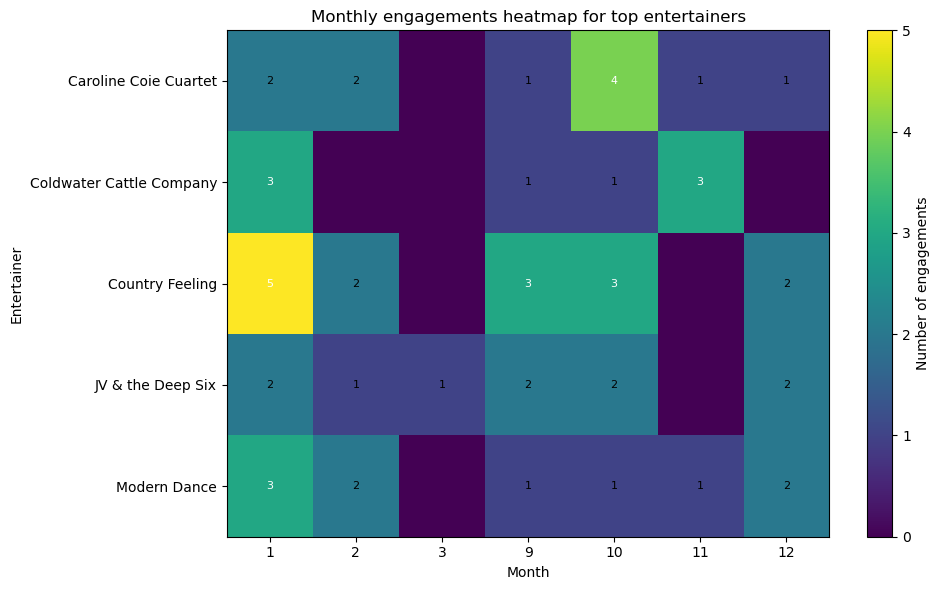

In [72]:
# seasonal Heatmap热力图

# ===== 图：Seasonal engagements heatmap for top entertainers =====

import numpy as np

# 确保 StartDate 是 datetime
eng['StartDate'] = pd.to_datetime(eng['StartDate'])
eng['Month'] = eng['StartDate'].dt.month

# 如果 top5_rev 没有提前算过，就先算一次
try:
    top5_ids = top5_rev['EntertainerID'].tolist()
except NameError:
    revenue2 = (
        eng.groupby('EntertainerID')['ContractPrice']
           .sum()
           .reset_index(name='total_revenue')
    )
    revenue2 = revenue2.merge(
        ent[['EntertainerID', 'EntStageName']],
        on='EntertainerID',
        how='left'
    )
    top5_rev = revenue2.sort_values('total_revenue', ascending=False).head(5)
    top5_ids = top5_rev['EntertainerID'].tolist()

# 只保留 top entertainers 的记录
eng_top = eng[eng['EntertainerID'].isin(top5_ids)]

# 每个 Entertainer-月份 的 booking 数
month_counts = (
    eng_top.groupby(['EntertainerID', 'Month'])['EngagementNumber']
           .count()
           .reset_index(name='num_engagements')
)

# 合并艺名
month_counts = month_counts.merge(
    ent[['EntertainerID', 'EntStageName']],
    on='EntertainerID', how='left'
)

# 透视：行=艺人，列=月份
pivot_hm = month_counts.pivot(
    index='EntStageName',
    columns='Month',
    values='num_engagements'
).fillna(0)

# 画热力图
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(pivot_hm.values, aspect='auto')

# 坐标轴刻度
ax.set_xticks(range(len(pivot_hm.columns)))
ax.set_xticklabels(pivot_hm.columns)
ax.set_yticks(range(len(pivot_hm.index)))
ax.set_yticklabels(pivot_hm.index)

ax.set_xlabel('Month')
ax.set_ylabel('Entertainer')
ax.set_title('Monthly engagements heatmap for top entertainers')

# 在格子里标数字
max_val = pivot_hm.values.max()
for i in range(pivot_hm.shape[0]):
    for j in range(pivot_hm.shape[1]):
        val = pivot_hm.iloc[i, j]
        if val > 0:
            ax.text(
                j, i, int(val),
                ha='center', va='center',
                fontsize=8,
                color='white' if val >= max_val / 2 else 'black'
            )

# 颜色条
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of engagements')

plt.tight_layout()
plt.show()

In [ ]:
##AGENT anaylysis

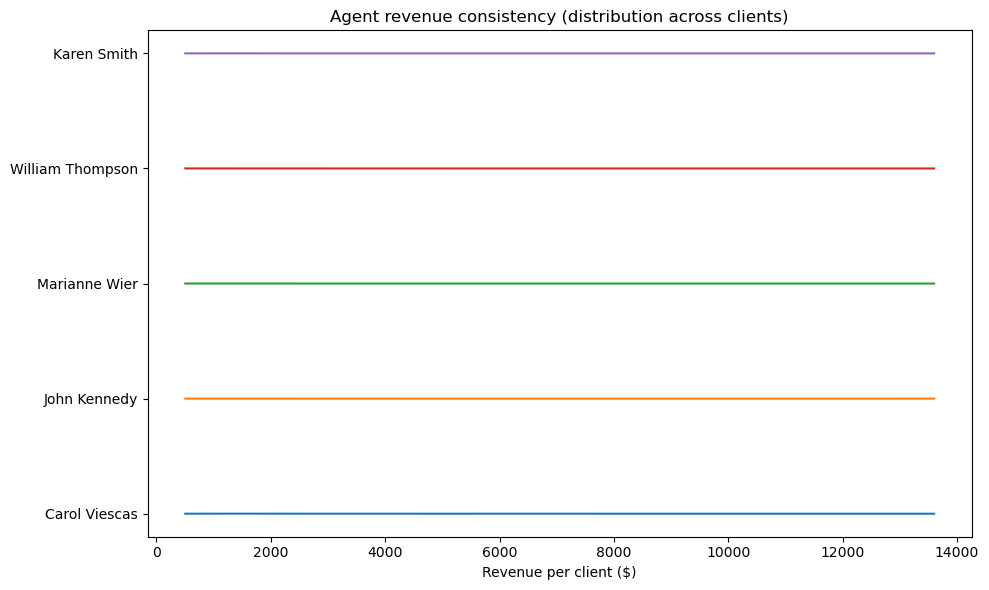

In [74]:
#1. Agent Revenue Consistency → Ridgeline Plot（山脊图）? 没懂要干啥
# ===== 图：Agent revenue consistency – Ridgeline plot =====
import numpy as np

# 1. 先算每个 agent 对每个 customer 的总收入
eng_agent_cust = eng.merge(
    agent[['AgentID', 'AgtFirstName', 'AgtLastName']],
    on='AgentID', how='left'
).merge(
    cust[['CustomerID', 'CustFirstName', 'CustLastName']],
    on='CustomerID', how='left'
)

eng_agent_cust['AgentName'] = eng_agent_cust['AgtFirstName'].fillna('') + ' ' + eng_agent_cust['AgtLastName'].fillna('')

rev_per_client = (
    eng_agent_cust.groupby(['AgentID', 'AgentName', 'CustomerID'])['ContractPrice']
                  .sum()
                  .reset_index(name='rev_per_client')
)

# 2. 选总收入最高的 top N agents
agent_tot_rev = (
    rev_per_client.groupby(['AgentID', 'AgentName'])['rev_per_client']
                  .sum()
                  .reset_index(name='total_revenue')
    .sort_values('total_revenue', ascending=False)
)

TOP_N = 5
top_agents = agent_tot_rev.head(TOP_N)['AgentID'].tolist()
rev_top = rev_per_client[rev_per_client['AgentID'].isin(top_agents)].copy()

# 3. 准备统一的分箱（所有 agent 共用）
max_rev = rev_top['rev_per_client'].max()
if max_rev == 0:
    max_rev = 1  # 防止全 0 的极端情况

bins = np.linspace(0, max_rev, 15)

# 4. 画 ridgeline（每个 agent 一条“山”）
fig, ax = plt.subplots(figsize=(10, 6))

agent_order = (
    agent_tot_rev[agent_tot_rev['AgentID'].isin(top_agents)]
    .sort_values('total_revenue', ascending=False)
)

y_gap = 1.2  # 垂直间距

for idx, row in enumerate(agent_order.itertuples()):
    aid = row.AgentID
    aname = row.AgentName
    sub = rev_top[rev_top['AgentID'] == aid]['rev_per_client']

    # 直方图（密度）
    hist, edges = np.histogram(sub, bins=bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])

    y_offset = idx * y_gap

    # 填充区域
    ax.fill_between(
        centers,
        y_offset,
        hist + y_offset,
        alpha=0.6
    )
    # 画一条轮廓线
    ax.plot(centers, hist + y_offset)

# 设置 y 轴为 agent 名字
ax.set_yticks([i * y_gap for i in range(len(agent_order))])
ax.set_yticklabels(agent_order['AgentName'])

ax.set_xlabel('Revenue per client ($)')
ax.set_title('Agent revenue consistency (distribution across clients)')

plt.tight_layout()
plt.show()

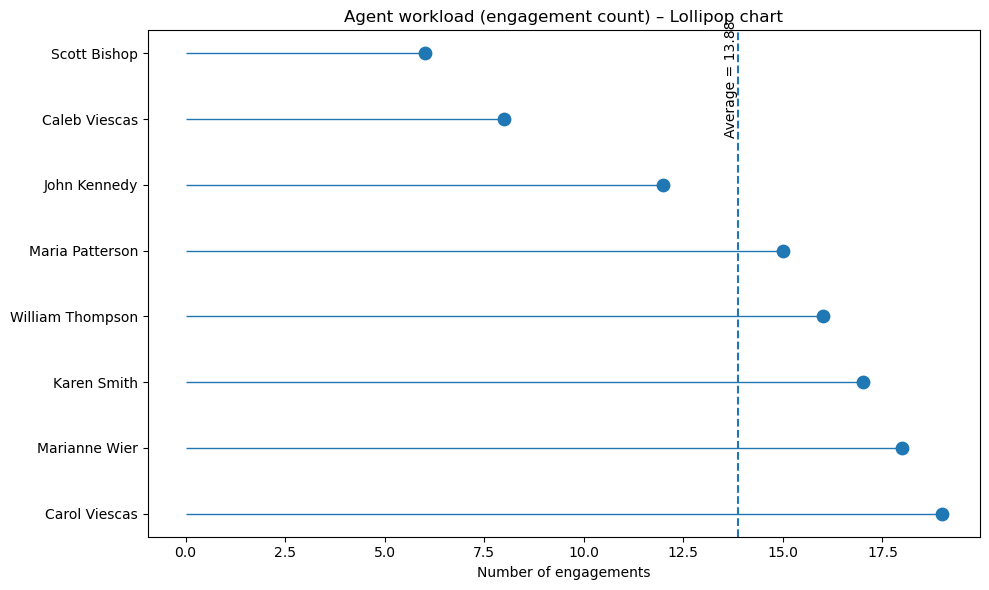

In [75]:
#2. Agent Workload → Lollipop Chart（棒棒糖图）：还可以

# ===== 图：Agent workload – Lollipop chart =====

# 1. 统计每个 agent 的工作量（engagement 数）
workload = (
    eng.groupby('AgentID')['EngagementNumber']
       .count()
       .reset_index(name='num_engagements')
)

# 2. 合并 agent 名字
workload = workload.merge(
    agent[['AgentID', 'AgtFirstName', 'AgtLastName']],
    on='AgentID', how='left'
)

workload['AgentName'] = workload['AgtFirstName'].fillna('') + ' ' + workload['AgtLastName'].fillna('')

# 3. 按工作量从高到低排序
workload = workload.sort_values('num_engagements', ascending=False)

# 4. 画棒棒糖图（水平）
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(workload))

# 线：从 0 画到对应值
ax.hlines(y=y_pos, xmin=0, xmax=workload['num_engagements'], linewidth=1)

# 点：终点的“糖”
ax.scatter(workload['num_engagements'], y_pos, s=80)

# y 轴刻度为 agent 名
ax.set_yticks(y_pos)
ax.set_yticklabels(workload['AgentName'])

ax.set_xlabel('Number of engagements')
ax.set_title('Agent workload (engagement count) – Lollipop chart')

# 标出平均线
avg = workload['num_engagements'].mean()
ax.axvline(avg, linestyle='--')
ax.text(
    avg, len(workload) - 0.5,
    f'Average = {avg:.2f}',
    rotation=90,
    va='top', ha='right'
)

plt.tight_layout()
plt.show()

In [79]:
#3. Agent–Client → Sankey Diagram（桑基图）:还可以

!pip install plotly

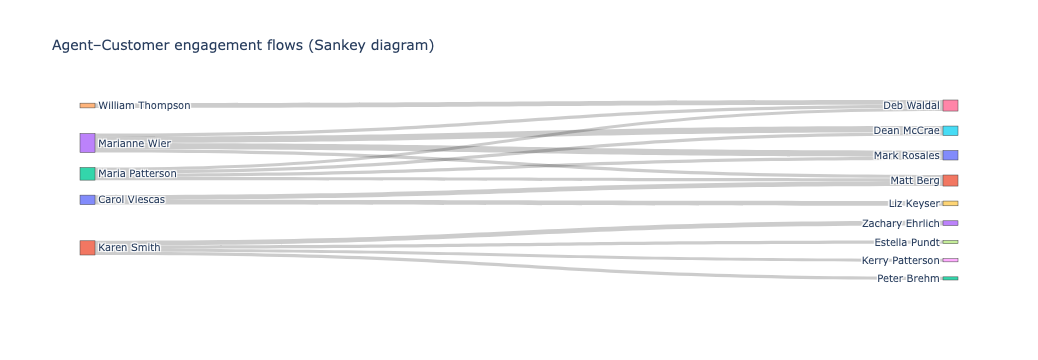

In [80]:
# ===== 图：Agent–Customer Sankey diagram =====
# 需要 plotly：如果没有，请先 pip install plotly
try:
    import plotly.graph_objects as go
except ImportError:
    print("本段代码需要 plotly 库，请先运行：pip install plotly")
else:
    # 1. Agent – Customer – Engagement 关联
    ac = eng.merge(
        agent[['AgentID', 'AgtFirstName', 'AgtLastName']],
        on='AgentID', how='left'
    ).merge(
        cust[['CustomerID', 'CustFirstName', 'CustLastName']],
        on='CustomerID', how='left'
    )

    ac['AgentName'] = ac['AgtFirstName'].fillna('') + ' ' + ac['AgtLastName'].fillna('')
    ac['CustomerName'] = ac['CustFirstName'].fillna('') + ' ' + ac['CustLastName'].fillna('')

    # 2. 按 agent-client 聚合：多少个 engagements
    flows = (
        ac.groupby(['AgentName', 'CustomerName'])['EngagementNumber']
          .count()
          .reset_index(name='num_engagements')
    )

    # 3. 选 top N agents（按总 engagements）
    agent_tot = (
        flows.groupby('AgentName')['num_engagements']
             .sum()
             .reset_index(name='tot_eng')
             .sort_values('tot_eng', ascending=False)
    )
    TOP_AGENTS = 5
    top_agent_names = agent_tot.head(TOP_AGENTS)['AgentName'].tolist()

    flows_top = flows[flows['AgentName'].isin(top_agent_names)].copy()

    # 4. 只保留最粗的若干条连线，避免太乱
    flows_top = flows_top.sort_values('num_engagements', ascending=False)
    TOP_LINKS = 15
    flows_top = flows_top.head(TOP_LINKS)

    # 5. 构建节点列表（先 agent，再 customer）
    agent_nodes = sorted(flows_top['AgentName'].unique().tolist())
    cust_nodes = sorted(flows_top['CustomerName'].unique().tolist())

    labels = agent_nodes + cust_nodes

    # 构建 label -> index 映射
    label_to_idx = {lab: i for i, lab in enumerate(labels)}

    # 6. 构建 Sankey 的 source / target / value
    sources = []
    targets = []
    values = []

    for row in flows_top.itertuples():
        a = row.AgentName
        c = row.CustomerName
        v = row.num_engagements
        sources.append(label_to_idx[a])
        targets.append(label_to_idx[c])
        values.append(v)

    # 7. 画 Sankey 图
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=15,
            label=labels
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values
        )
    )])

    fig.update_layout(
        title_text="Agent–Customer engagement flows (Sankey diagram)",
        font_size=10
    )

    fig.show()


In [ ]:
#Customer Analysis

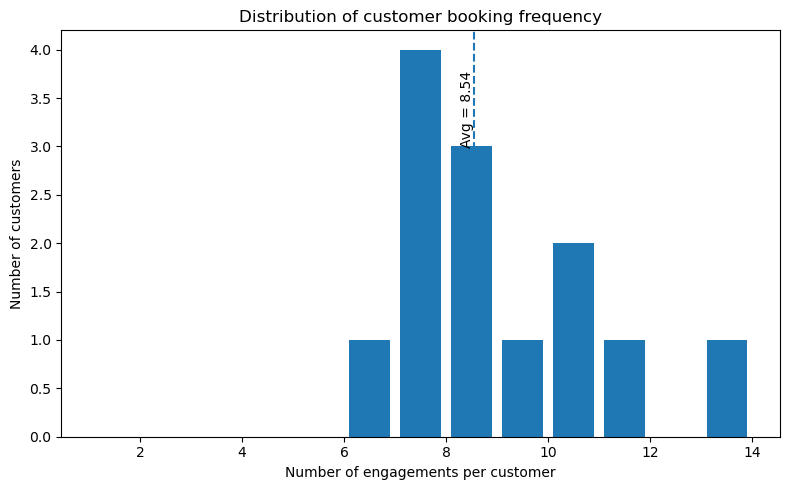

In [81]:
# ===== 图1：Customer booking frequency – Histogram =====
import numpy as np

# 每个客户的总预订次数
bookings_per_cust = (
    eng.groupby('CustomerID')['EngagementNumber']
       .count()
       .reset_index(name='num_bookings')
)

# 画直方图
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(bookings_per_cust['num_bookings'], bins=range(1, bookings_per_cust['num_bookings'].max() + 2), rwidth=0.8)

ax.set_xlabel('Number of engagements per customer')
ax.set_ylabel('Number of customers')
ax.set_title('Distribution of customer booking frequency')

# 标出平均值
mean_val = bookings_per_cust['num_bookings'].mean()
ax.axvline(mean_val, linestyle='--')
ax.text(mean_val, ax.get_ylim()[1] * 0.9, f'Avg = {mean_val:.2f}', rotation=90,
        va='top', ha='right')

plt.tight_layout()
plt.show()

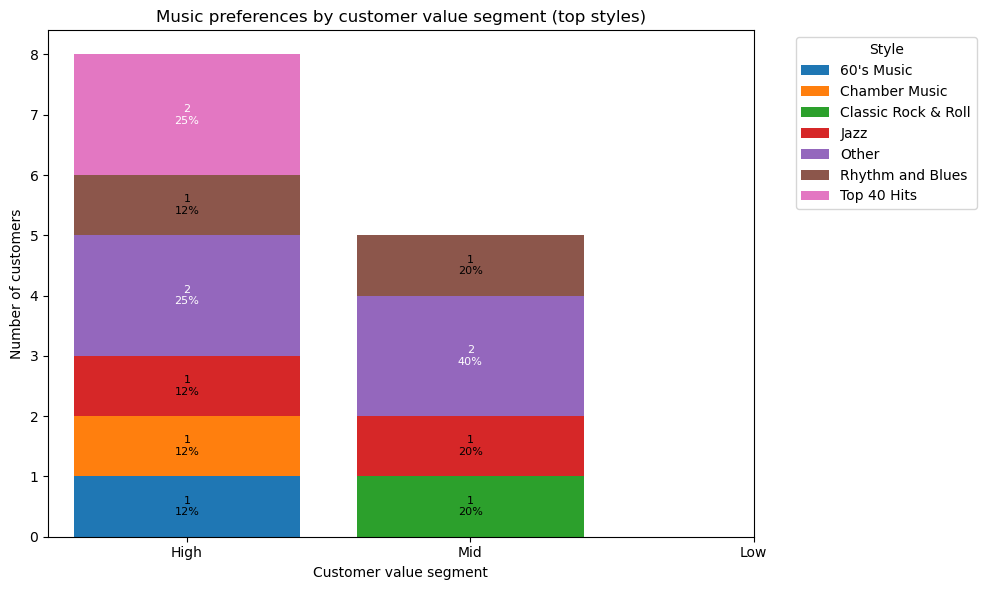

In [86]:
#2:Music Preferences by Customer Value Segment → Stacked Bar（堆叠柱状图）
# ===== 图2：Music preferences by customer value segment – Stacked bar =====

# 1. 基于预订次数给客户分价值段
def segment_booking(n):
    if n >= 8:
        return 'High'
    elif n >= 3:
        return 'Mid'
    else:
        return 'Low'

bookings_per_cust['ValueSegment'] = bookings_per_cust['num_bookings'].apply(segment_booking)

# 2. 取客户的首选音乐风格（PreferenceSeq = 1）
mp_top = mp[mp['PreferenceSeq'] == 1].copy()

# 合并客户价值段
mp_seg = mp_top.merge(
    bookings_per_cust[['CustomerID', 'ValueSegment']],
    on='CustomerID',
    how='inner'
)

# 合并 Style 名字
mp_seg = mp_seg.merge(
    ms[['StyleID', 'StyleName']],
    on='StyleID',
    how='left'
)

# 3. 统计 ValueSegment × StyleName 组合数量
seg_style_counts = (
    mp_seg.groupby(['ValueSegment', 'StyleName'])['CustomerID']
          .nunique()
          .reset_index(name='num_customers')
)

# 为了图更清晰，只保留整体 top N style，其余归为 'Other'
overall_style_counts = (
    seg_style_counts.groupby('StyleName')['num_customers']
                    .sum()
                    .sort_values(ascending=False)
)

TOP_STYLES = 6
top_styles = overall_style_counts.head(TOP_STYLES).index.tolist()

seg_style_counts['StyleName_clean'] = seg_style_counts['StyleName'].where(
    seg_style_counts['StyleName'].isin(top_styles),
    'Other'
)

seg_style_summary = (
    seg_style_counts.groupby(['ValueSegment', 'StyleName_clean'])['num_customers']
                    .sum()
                    .reset_index()
)

# 透视表：行 = ValueSegment，列 = Style
pivot_seg_style = seg_style_summary.pivot(
    index='ValueSegment',
    columns='StyleName_clean',
    values='num_customers'
).fillna(0)

# 按 High/Mid/Low 排序行
order_segments = ['High', 'Mid', 'Low']
pivot_seg_style = pivot_seg_style.reindex(order_segments)

# 4. 堆叠柱状图
# 4. 堆叠柱状图 + 每块里显示“次数 + 占比”
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(pivot_seg_style.index))
bottom = np.zeros(len(pivot_seg_style))

# 每个 segment（High/Mid/Low）的总人数，用来算百分比
segment_totals = pivot_seg_style.sum(axis=1).values

for style in pivot_seg_style.columns:
    values = pivot_seg_style[style].values
    
    # 画这一层
    ax.bar(x, values, bottom=bottom, label=style)
    
    # 在每一块中间写上 数量 + 百分比
    for i, (val, btm) in enumerate(zip(values, bottom)):
        if val > 0:
            pct = val / segment_totals[i] * 100
            ax.text(
                x[i],
                btm + val / 2,                 # 在这一块的垂直中间
                f'{int(val)}\n{pct:.0f}%',   # 例如：2\n(25%)
                ha='center',
                va='center',
                fontsize=8,
                color='white' if val >= 2 else 'black'  # 小块用黑字，大块用白字
            )
    
    # 更新下一层的 bottom
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(pivot_seg_style.index)
ax.set_xlabel('Customer value segment')
ax.set_ylabel('Number of customers')
ax.set_title('Music preferences by customer value segment (top styles)')

ax.legend(title='Style', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

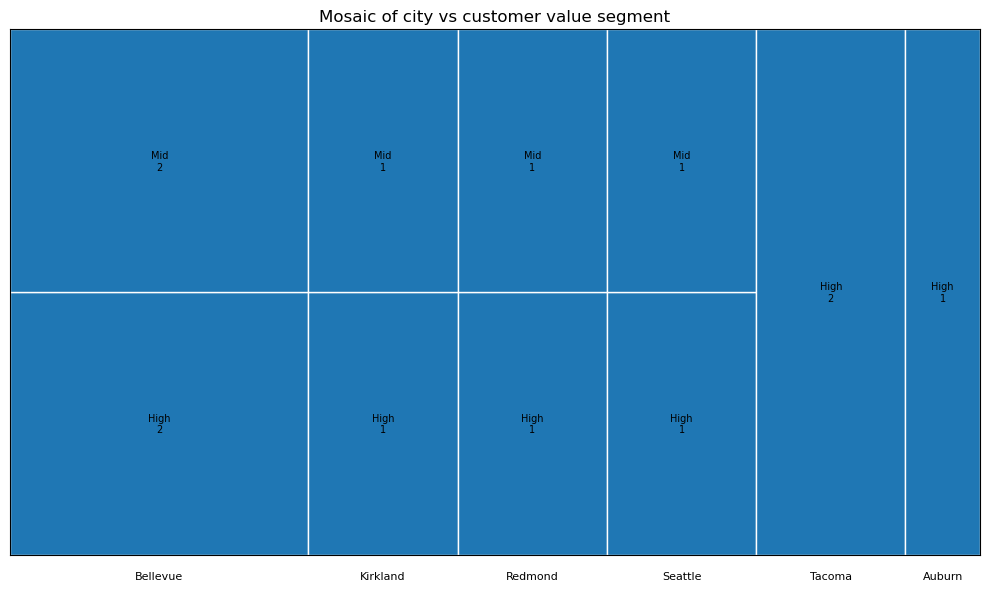

In [83]:
#3 City × Customer Value Segment → Mosaic Plot（马赛克拼块图）

# ===== 图3：City vs customer value segment – Mosaic plot =====
from matplotlib.patches import Rectangle

# 1. 把客户价值段信息合并到 Customers
cust_seg = cust.merge(
    bookings_per_cust[['CustomerID', 'ValueSegment']],
    on='CustomerID',
    how='left'
).dropna(subset=['ValueSegment'])

# 2. 只保留客户数最多的前 N 个城市，其余归为 'Other'
city_counts = (
    cust_seg.groupby('CustCity')['CustomerID']
            .nunique()
            .sort_values(ascending=False)
)

TOP_CITIES = 6
top_cities = city_counts.head(TOP_CITIES).index.tolist()

cust_seg['City_clean'] = cust_seg['CustCity'].where(
    cust_seg['CustCity'].isin(top_cities),
    'Other'
)

# 3. 交叉表：City × Segment（用人数）
ctab = pd.crosstab(cust_seg['City_clean'], cust_seg['ValueSegment'])

# 按城市总人数排序
ctab = ctab.loc[ctab.sum(axis=1).sort_values(ascending=False).index]

# 行、列
cities = ctab.index.tolist()
segments = sorted(ctab.columns.tolist())

total = ctab.values.sum()

fig, ax = plt.subplots(figsize=(10, 6))

x0 = 0.0
# 4. 手动画 Mosaic：横向按城市，纵向按价值段分块
for city in cities:
    row = ctab.loc[city]
    row_total = row.sum()
    if row_total == 0:
        continue

    width = row_total / total  # 该城市在横轴占比
    y0 = 0.0

    for seg in segments:
        value = row[seg]
        if value == 0:
            continue
        height = value / row_total  # 在当前城市内部的纵向比例

        # 画矩形
        rect = Rectangle((x0, y0), width, height, edgecolor='white')
        ax.add_patch(rect)

        # 在块中间写标签（人数）
        ax.text(
            x0 + width / 2,
            y0 + height / 2,
            f'{seg}\n{int(value)}',
            ha='center', va='center',
            fontsize=7
        )

        y0 += height

    # 在城市下方写城市名
    ax.text(
        x0 + width / 2,
        -0.03,
        city,
        ha='center', va='top',
        fontsize=8,
        rotation=0
    )

    x0 += width

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Mosaic of city vs customer value segment')

plt.tight_layout()
plt.show()